# Week 2: Quantum kernels vs classical models on identical compressed features

This notebook loads the week 1 outputs and compares:

- **Quantum kernel SVMs**: ZZ feature map, linear entanglement, reps 1 and 2, at 4, 6 and 8 qubits (6 kernels).
- **Classical models** on exactly the same inputs: RBF-SVM and logistic regression.

It uses **repeat 0 only** (5 folds), with the same splits and the same fold-wise PCA features saved in week 1.
Nothing is refitted on test data. Kernels are computed by exact statevector simulation, so there is no shot noise.

Diagnostics per kernel and fold: off-diagonal mean and variance (kernel concentration) and centered kernel-target alignment.

Requirements: `pip install qiskit` (tested with Qiskit 2.x). Qiskit Machine Learning is not needed.

## 0. Configuration

In [2]:
%pip install qiskit

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   -------------------------- ------------- 6.3/9.5 MB 35.5 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 29.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 35.0 MB/s eta 0:00:00

   ------------- -------------------------- 1/3 [rustworkx]
   -------------------------- ------------- 2/3 [qiskit]
   -------------------------- ------------- 2/3 [qiskit]
   -------------------------- ------------- 2/3 [qiskit]
   -------------------------- ------------- 2/3 [qiskit]
   -------------------------- ------------- 2/3 [qiskit]
   -------------------------- ------------- 2/3 [qiskit]
   -------------------------- ------------- 2/3 [qiskit]
   -------------------------- ------------- 2/3 [qiskit]
   -------------------------- ------------- 2/3 [qiskit]
   -------------------------- ------------- 2/3 [qiskit]


In [11]:
import json, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit.circuit.library import zz_feature_map
from qiskit.quantum_info import Statevector

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
WEEK1_DIR = Path("outputs/week1")
OUT_DIR = Path("outputs/week2")
KERNEL_DIR = OUT_DIR / "kernels"
OUT_DIR.mkdir(parents=True, exist_ok=True)
KERNEL_DIR.mkdir(parents=True, exist_ok=True)

QUBITS = [4, 6, 8]           # must match the PCA sizes saved in week 1
REPS = [1, 2]
ENTANGLEMENT = "linear"
REPEATS = [0]                # add 1, 2 later if you want more repeats
N_FOLDS = 5
C_GRID = [0.1, 1.0, 10.0, 100.0]
# Bandwidth scales the inputs before encoding (x -> bw * x). Smaller values reduce kernel
# concentration. Keep [1.0] for the first run; if the concentration plot shows values piled
# up near 0, re-run with [1.0, 0.25]. Report every bandwidth you try; never pick one by test score.
BANDWIDTHS = [1.0, 0.5, 0.25, 0.1]

meta = json.load(open(WEEK1_DIR / "meta.json"))
CLASSES = meta["classes"]
K = len(CLASSES)
print("Classes:", CLASSES)

Classes: ['Basal', 'Her2', 'LumA', 'LumB', 'Normal']


## 1. Metrics (same as week 1)

In [12]:
def score(y_true, proba):
    pred = proba.argmax(axis=1)
    return {"bal_acc": balanced_accuracy_score(y_true, pred),
            "macro_f1": f1_score(y_true, pred, average="macro"),
            "macro_auc": roc_auc_score(y_true, proba, multi_class="ovr",
                                       average="macro", labels=np.arange(K))}

## 2. Quantum kernel and diagnostics

Each sample x is encoded as the state |phi(x)> produced by the ZZ feature map.
The kernel is the fidelity k(x, x') = |<phi(x)|phi(x')>|^2.
All statevectors are computed once per fold, then the kernel matrix comes from one matrix product.

In [13]:
def statevectors(X, n_qubits, reps):
    fmap = zz_feature_map(n_qubits, reps=reps, entanglement=ENTANGLEMENT)
    params = list(fmap.parameters)          # ordered x[0], x[1], ...
    assert len(params) == X.shape[1], "feature count must equal qubit count"
    out = np.empty((X.shape[0], 2 ** n_qubits), dtype=complex)
    for i, x in enumerate(X):
        out[i] = Statevector(fmap.assign_parameters(dict(zip(params, x)))).data
    return out

def fidelity_kernel(SA, SB):
    return np.abs(SA @ SB.conj().T) ** 2

def centered_kta(Kmat, y):
    n = len(y)
    Y = np.eye(K)[y]
    H = np.eye(n) - np.ones((n, n)) / n
    Kc, Yc = H @ Kmat @ H, H @ (Y @ Y.T) @ H
    return float(np.sum(Kc * Yc) / (np.linalg.norm(Kc) * np.linalg.norm(Yc)))

def offdiag(Kmat):
    return Kmat[~np.eye(Kmat.shape[0], dtype=bool)]

## 3. Models

For the quantum kernel SVM, C is chosen by an inner 3-fold CV that slices the **train-train** kernel.
The test fold is never used to choose C. Classical models use the same C grid on the same inputs.

In [14]:
def fit_precomputed_svc(K_tr, y_tr):
    inner = StratifiedKFold(3, shuffle=True, random_state=SEED)
    best_C, best_s = None, -1.0
    for C in C_GRID:
        s = []
        for a, b in inner.split(np.zeros(len(y_tr)), y_tr):
            m = SVC(kernel="precomputed", C=C, class_weight="balanced")
            m.fit(K_tr[np.ix_(a, a)], y_tr[a])
            s.append(balanced_accuracy_score(y_tr[b], m.predict(K_tr[np.ix_(b, a)])))
        if np.mean(s) > best_s:
            best_C, best_s = C, float(np.mean(s))
    model = SVC(kernel="precomputed", C=best_C, class_weight="balanced",
                probability=True, random_state=SEED).fit(K_tr, y_tr)
    return model, best_C

def tuned(est, grid):
    return GridSearchCV(est, grid, scoring="balanced_accuracy",
                        cv=StratifiedKFold(3, shuffle=True, random_state=SEED), n_jobs=-1)

def classical_models():
    return {
        "SVM_RBF": tuned(SVC(kernel="rbf", gamma="scale", class_weight="balanced",
                             probability=True, random_state=SEED), {"C": C_GRID}),
        "LogReg_L2": tuned(LogisticRegression(max_iter=5000, class_weight="balanced"),
                           {"C": [0.01, 0.1, 1.0, 10.0]}),
    }

## 4. Run all models

In [15]:
rows, offdiag_store = [], {}
t_start = time.time()
for q in QUBITS:
    data = np.load(WEEK1_DIR / f"compressed_pca{q}.npz")
    for r in REPEATS:
        for f in range(N_FOLDS):
            key = f"r{r}_f{f}"
            Xtr, Xte = data[f"{key}_Xtr"], data[f"{key}_Xte"]
            ytr, yte = data[f"{key}_ytr"], data[f"{key}_yte"]

            for reps in REPS:
              for bw in BANDWIDTHS:
                t0 = time.time()
                S_tr, S_te = statevectors(bw * Xtr, q, reps), statevectors(bw * Xte, q, reps)
                K_tr, K_te = fidelity_kernel(S_tr, S_tr), fidelity_kernel(S_te, S_tr)
                np.savez_compressed(KERNEL_DIR / f"zz_q{q}_reps{reps}_bw{bw}_{key}.npz", K_tr=K_tr, K_te=K_te)
                model, C = fit_precomputed_svc(K_tr, ytr)
                od = offdiag(K_tr)
                if r == REPEATS[0] and f == 0:
                    offdiag_store[(q, reps, bw)] = od
                rows.append({"model": "QSVM", "kernel": f"ZZ-reps{reps}-bw{bw}", "qubits": q, "bandwidth": bw,
                             "repeat": r, "fold": f, "C": C,
                             **score(yte, model.predict_proba(K_te)),
                             "kta": centered_kta(K_tr, ytr),
                             "offdiag_mean": od.mean(), "offdiag_var": od.var(),
                             "runtime_s": time.time() - t0})

            for name, est in classical_models().items():
                t0 = time.time()
                m = est.fit(Xtr, ytr)
                rows.append({"model": name, "kernel": "classical", "qubits": q, "bandwidth": np.nan,
                             "repeat": r, "fold": f, "C": m.best_params_["C"],
                             **score(yte, m.predict_proba(Xte)),
                             "kta": np.nan, "offdiag_mean": np.nan, "offdiag_var": np.nan,
                             "runtime_s": time.time() - t0})
    print(f"{q} qubits done ({time.time() - t_start:.0f}s elapsed)")

results = pd.DataFrame(rows)
results["config"] = np.where(results["model"] == "QSVM",
                             "QSVM " + results["kernel"], results["model"])
results.to_csv(OUT_DIR / "results_per_fold.csv", index=False)

4 qubits done (90s elapsed)
6 qubits done (330s elapsed)
8 qubits done (572s elapsed)


## 5. Summary table (mean and std over folds)

In [18]:
summary = (results.groupby(["qubits", "config"])
                  [["bal_acc", "macro_f1", "macro_auc", "kta", "offdiag_var"]]
                  .agg(["mean", "std"]).round(3))
summary.to_csv(OUT_DIR / "summary.csv")
summary

bal_acc        macro_f1        macro_auc         \
                               mean    std     mean    std      mean    std   
qubits config                                                                 
4      LogReg_L2              0.825  0.045    0.746  0.021     0.960  0.012   
       QSVM ZZ-reps1-bw0.1    0.693  0.040    0.718  0.043     0.956  0.014   
       QSVM ZZ-reps1-bw0.25   0.679  0.053    0.691  0.059     0.950  0.012   
       QSVM ZZ-reps1-bw0.5    0.622  0.068    0.619  0.067     0.927  0.028   
       QSVM ZZ-reps1-bw1.0    0.520  0.047    0.518  0.039     0.889  0.045   
       QSVM ZZ-reps2-bw0.1    0.712  0.033    0.733  0.028     0.957  0.015   
       QSVM ZZ-reps2-bw0.25   0.652  0.083    0.658  0.080     0.943  0.012   
       QSVM ZZ-reps2-bw0.5    0.582  0.048    0.586  0.052     0.912  0.025   
       QSVM ZZ-reps2-bw1.0    0.464  0.052    0.485  0.064     0.841  0.044   
       SVM_RBF                0.729  0.034    0.742  0.026     0.957  0.015   
6      LogReg_L2              0.813  0.062    0.747  0.048     0.962  0.012   
       QSVM ZZ-reps1-bw0.1    0.725  0.039    0.751  0.025     0.949  0.009   
       QSVM ZZ-reps1-bw0.25   0.628  0.058    0.626  0.064     0.929  0.021   
       QSVM ZZ-reps1-bw0.5    0.553  0.076    0.559  0.069     0.913  0.023   
       QSVM ZZ-reps1-bw1.0    0.472  0.045    0.475  0.047     0.861  0.034   
       QSVM ZZ-reps2-bw0.1    0.669  0.032    0.691  0.023     0.945  0.011   
       QSVM ZZ-reps2-bw0.25   0.613  0.047    0.616  0.057     0.921  0.019   
       QSVM ZZ-reps2-bw0.5    0.520  0.039    0.538  0.053     0.889  0.017   
       QSVM ZZ-reps2-bw1.0    0.378  0.035    0.393  0.040     0.783  0.017   
       SVM_RBF                0.700  0.037    0.710  0.052     0.956  0.011   
8      LogReg_L2              0.809  0.058    0.741  0.044     0.965  0.012   
       QSVM ZZ-reps1-bw0.1    0.696  0.065    0.704  0.066     0.954  0.010   
       QSVM ZZ-reps1-bw0.25   0.654  0.046    0.661  0.053     0.934  0.016   
       QSVM ZZ-reps1-bw0.5    0.595  0.046    0.603  0.050     0.908  0.013   
       QSVM ZZ-reps1-bw1.0    0.437  0.034    0.444  0.032     0.838  0.028   
       QSVM ZZ-reps2-bw0.1    0.718  0.052    0.722  0.041     0.949  0.011   
       QSVM ZZ-reps2-bw0.25   0.601  0.031    0.603  0.033     0.916  0.022   
       QSVM ZZ-reps2-bw0.5    0.493  0.048    0.500  0.039     0.869  0.014   
       QSVM ZZ-reps2-bw1.0    0.357  0.012    0.369  0.015     0.762  0.050   
       SVM_RBF                0.725  0.018    0.746  0.018     0.960  0.007   

                               kta        offdiag_var         
                              mean    std        mean    std  
qubits config                                                 
4      LogReg_L2               NaN    NaN         NaN    NaN  
       QSVM ZZ-reps1-bw0.1   0.273  0.105       0.043  0.001  
       QSVM ZZ-reps1-bw0.25  0.277  0.066       0.075  0.004  
       QSVM ZZ-reps1-bw0.5   0.196  0.032       0.031  0.003  
       QSVM ZZ-reps1-bw1.0   0.134  0.021       0.015  0.002  
       QSVM ZZ-reps2-bw0.1   0.275  0.090       0.059  0.002  
       QSVM ZZ-reps2-bw0.25  0.223  0.042       0.048  0.003  
       QSVM ZZ-reps2-bw0.5   0.127  0.018       0.020  0.002  
       QSVM ZZ-reps2-bw1.0   0.096  0.012       0.011  0.001  
       SVM_RBF                 NaN    NaN         NaN    NaN  
6      LogReg_L2               NaN    NaN         NaN    NaN  
       QSVM ZZ-reps1-bw0.1   0.244  0.083       0.047  0.001  
       QSVM ZZ-reps1-bw0.25  0.234  0.044       0.038  0.003  
       QSVM ZZ-reps1-bw0.5   0.154  0.017       0.008  0.001  
       QSVM ZZ-reps1-bw1.0   0.103  0.008       0.002  0.000  
       QSVM ZZ-reps2-bw0.1   0.249  0.075       0.055  0.001  
       QSVM ZZ-reps2-bw0.25  0.204  0.031       0.018  0.002  
       QSVM ZZ-reps2-bw0.5   0.107  0.014       0.004  0.000  
       QSVM ZZ-reps2-bw1.0   0.082  0.007       0.001  0.000  
       SVM_RBF                 NaN

## 6. Figures: accuracy comparison and kernel concentration

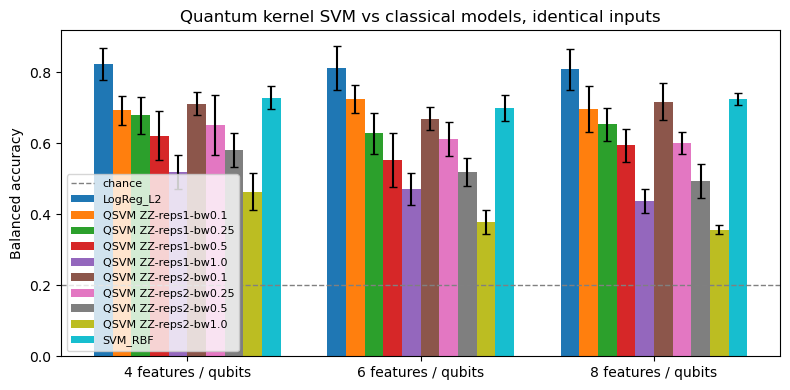

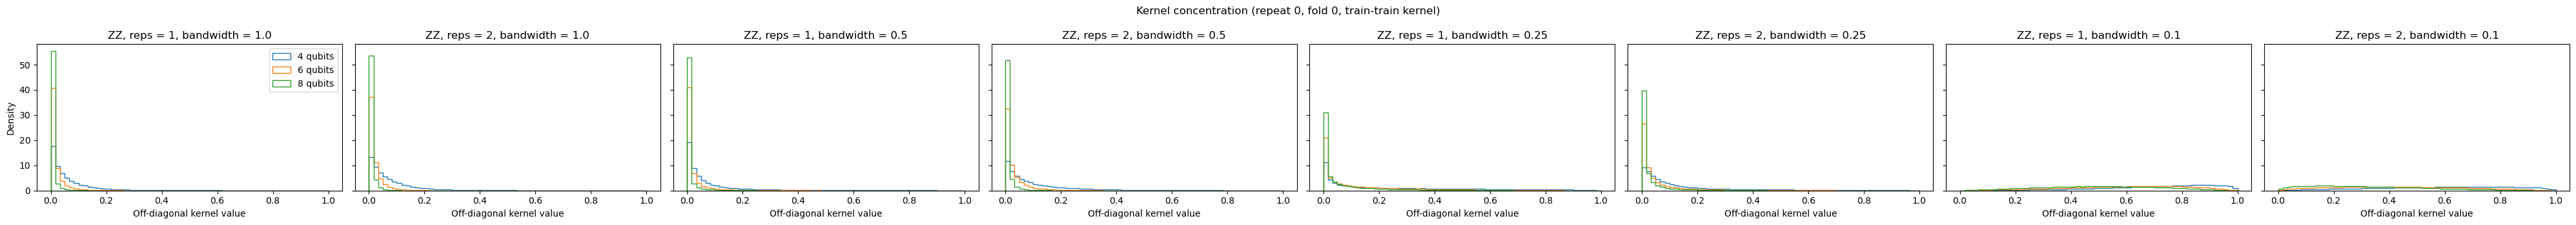

In [19]:
configs = sorted(results["config"].unique())
pivot = results.groupby(["qubits", "config"])["bal_acc"].agg(["mean", "std"]).reset_index()
fig, ax = plt.subplots(figsize=(8, 4))
w = 0.8 / len(configs)
for j, c in enumerate(configs):
    sub = pivot[pivot["config"] == c].set_index("qubits").loc[QUBITS]
    ax.bar(np.arange(len(QUBITS)) + (j - (len(configs) - 1) / 2) * w, sub["mean"], w,
           yerr=sub["std"], capsize=3, label=c)
ax.axhline(1 / K, ls="--", c="gray", lw=1, label="chance")
ax.set_xticks(np.arange(len(QUBITS)))
ax.set_xticklabels([f"{q} features / qubits" for q in QUBITS])
ax.set_ylabel("Balanced accuracy")
ax.set_title("Quantum kernel SVM vs classical models, identical inputs")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / "quantum_vs_classical.png", dpi=200)
plt.show()

panels = [(reps, bw) for bw in BANDWIDTHS for reps in REPS]
fig, axes = plt.subplots(1, len(panels), figsize=(5 * len(panels), 3.5), sharey=True)
axes = np.atleast_1d(axes)
for ax, (reps, bw) in zip(axes, panels):
    for q in QUBITS:
        ax.hist(offdiag_store[(q, reps, bw)], bins=60, range=(0, 1), histtype="step",
                density=True, lw=1.5, label=f"{q} qubits")
    ax.set_title(f"ZZ, reps = {reps}, bandwidth = {bw}")
    ax.set_xlabel("Off-diagonal kernel value")
axes[0].set_ylabel("Density")
axes[0].legend()
plt.suptitle("Kernel concentration (repeat 0, fold 0, train-train kernel)")
plt.tight_layout()
plt.savefig(OUT_DIR / "kernel_concentration.png", dpi=200)
plt.show()

## 7. What to look at

- Compare **QSVM** with **SVM_RBF** at the same qubit count. They see identical inputs, so any difference comes from the kernel.
- If off-diagonal values bunch up near 0 as qubits increase (small `offdiag_var`), the quantum kernel is concentrating, which usually explains weaker accuracy.
- If concentration is strong, re-run with `BANDWIDTHS = [1.0, 0.25]` and report both. Smaller bandwidth usually spreads the kernel values out.
- Higher `kta` means the kernel's similarity structure agrees more with the labels.

Files in `outputs/week2/`: `results_per_fold.csv`, `summary.csv`, `quantum_vs_classical.png`, `kernel_concentration.png`, and kernel matrices in `kernels/`.